In [20]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import ast
import seaborn as sns

run_id = "20251222_1046"

In [21]:
# --- 1. Global Academic Style Configuration ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # LaTeX math style
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'lines.linewidth': 2,
    'lines.markersize': 7,
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
})

In [22]:
# --- Path to your local folder ---
config_path = f"../results/run_{run_id}/configs.csv"
plot_path = f"../results/run_{run_id}/plots/"
os.makedirs(plot_path, exist_ok=True)

# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (15 rows) from ../results/run_20251222_1046/configs.csv


,D,L,beta,lam,Delta_in,samples,T,lr,norm_init,tol,N_test,rho_list,alpha_start,alpha_end,alpha_steps,base_dir,verbose,alpha_list,alpha,run_index
0,100,2,1.0,0.0,0.0,16,10000,0.01,1.0,0.000001,2000,"[0.3, 0.5, 1.0, 1.5]",0.01,0.4,15,/home/peucelle/tpiv-simulations/results/run_20...,True,[0.01],0.010000,0
1,100,2,1.0,0.0,0.0,16,10000,0.01,1.0,0.000001,2000,"[0.3, 0.5, 1.0, 1.5]",0.01,0.4,15,/home/peucelle/tpiv-simulations/results/run_20...,True,[0.03785714285714286],0.037857,1
2,100,2,1.0,0.0,0.0,16,10000,0.01,1.0,0.000001,2000,"[0.3, 0.5, 1.0, 1.5]",0.01,0.4,15,/home/peucelle/tpiv-simulations/results/run_20...,True,[0.06571428571428571],0.065714,2
3,100,2,1.0,0.0,0.0,16,10000,0.01,1.0,0.000001,2000,"[0.3, 0.5, 1.0, 1.5]",0.01,0.4,15,/home/peucelle/tpiv-simulations/results/run_20...,True,[0.09357142857142857],0.093571,3
4,100,2,1.0,0.0,0.0,16,10000,0.01,1.0,0.000001,2000,"[0.3, 0.5, 1.0, 1.5]",0.01,0.4,15,/home/peucelle/tpiv-simulations/results/run_20...,True,[0.12142857142857143],0.121429,4
5,100,2,1.0,0.0,0.0,16,10000,0.01,1.0,0.000001,2000,"[0.3, 0.5, 1.0, 1.5]",0.01,0.4,15,/home/peucelle/tpiv-simulations/results/run_20...,True,[0.1492857142857143],0.149286,5
6,100,2,1.0,0.0,0.0,16,10000,0.01,1.0,0.000001,2000,"[0.3, 0.5, 1.0, 1.5]",0.01,0.4,15,/home/peucelle/tpiv-simulations/results/run_20...,True,[0.17714285714285716],0.177143,6
7,100,2,1.0,0.0,0.0,16,10000,0.01,1.0,0.000001,2000,"[0.3, 0.5, 1.0, 1.5]",0.01,0.4,15,/home/peucelle/tpiv-simulations/results/run_20...,True,[0.37214285714285716],0.372143,13
8,100,2,1.0,0.0,0.0,16,10000,0.01,1.0,0.000001,2000,"[0.3, 0.5, 1.0, 1.5]",0.01,0.4,15,/home/peucelle/tpiv-simulations/results/run_20...,True,[0.4],0.400000,14
9,100,2,1.0,0.0,0.0,16,10000,0.01,1.0,0.000001,2000,"[0.3, 0.5, 1.0, 1.5]",0.01,0.4,15,/home/peucelle/tpiv-simulations/results/run_20...,True,[0.20500000000000002],0.205000,7


✅ Summary loaded (60 rows) from ../results/run_20251222_1046/summary.csv
✅ Saved plot: ../results/run_20251222_1046/plots/MSE_vs_alpha_run_20251222_1046.png


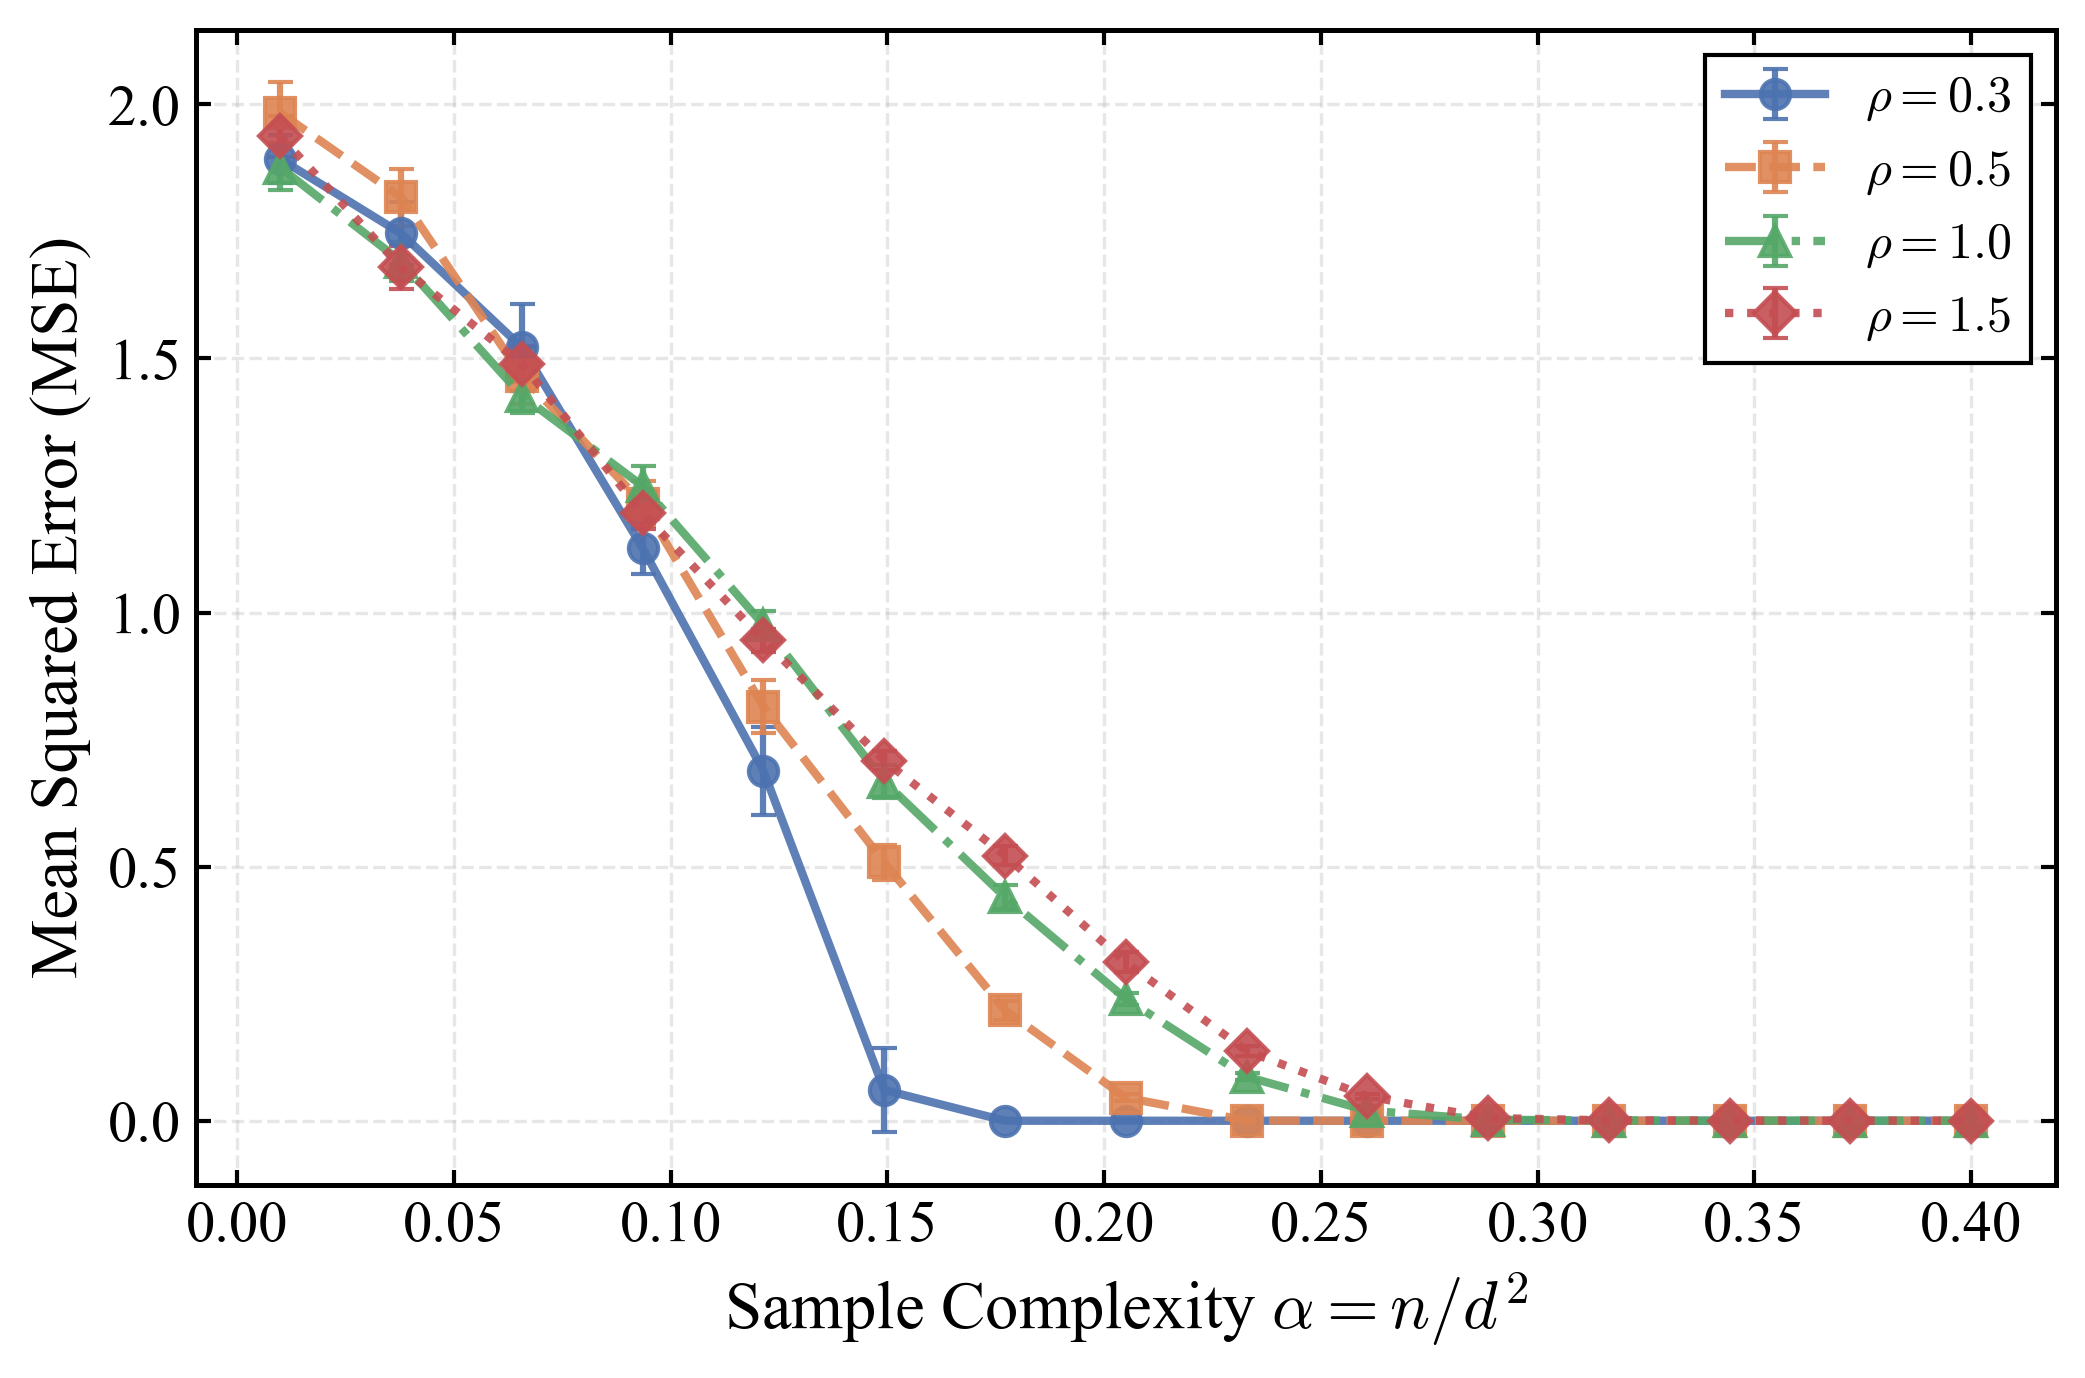

✅ Saved plot: ../results/run_20251222_1046/plots/LabelError_vs_alpha_run_20251222_1046.png


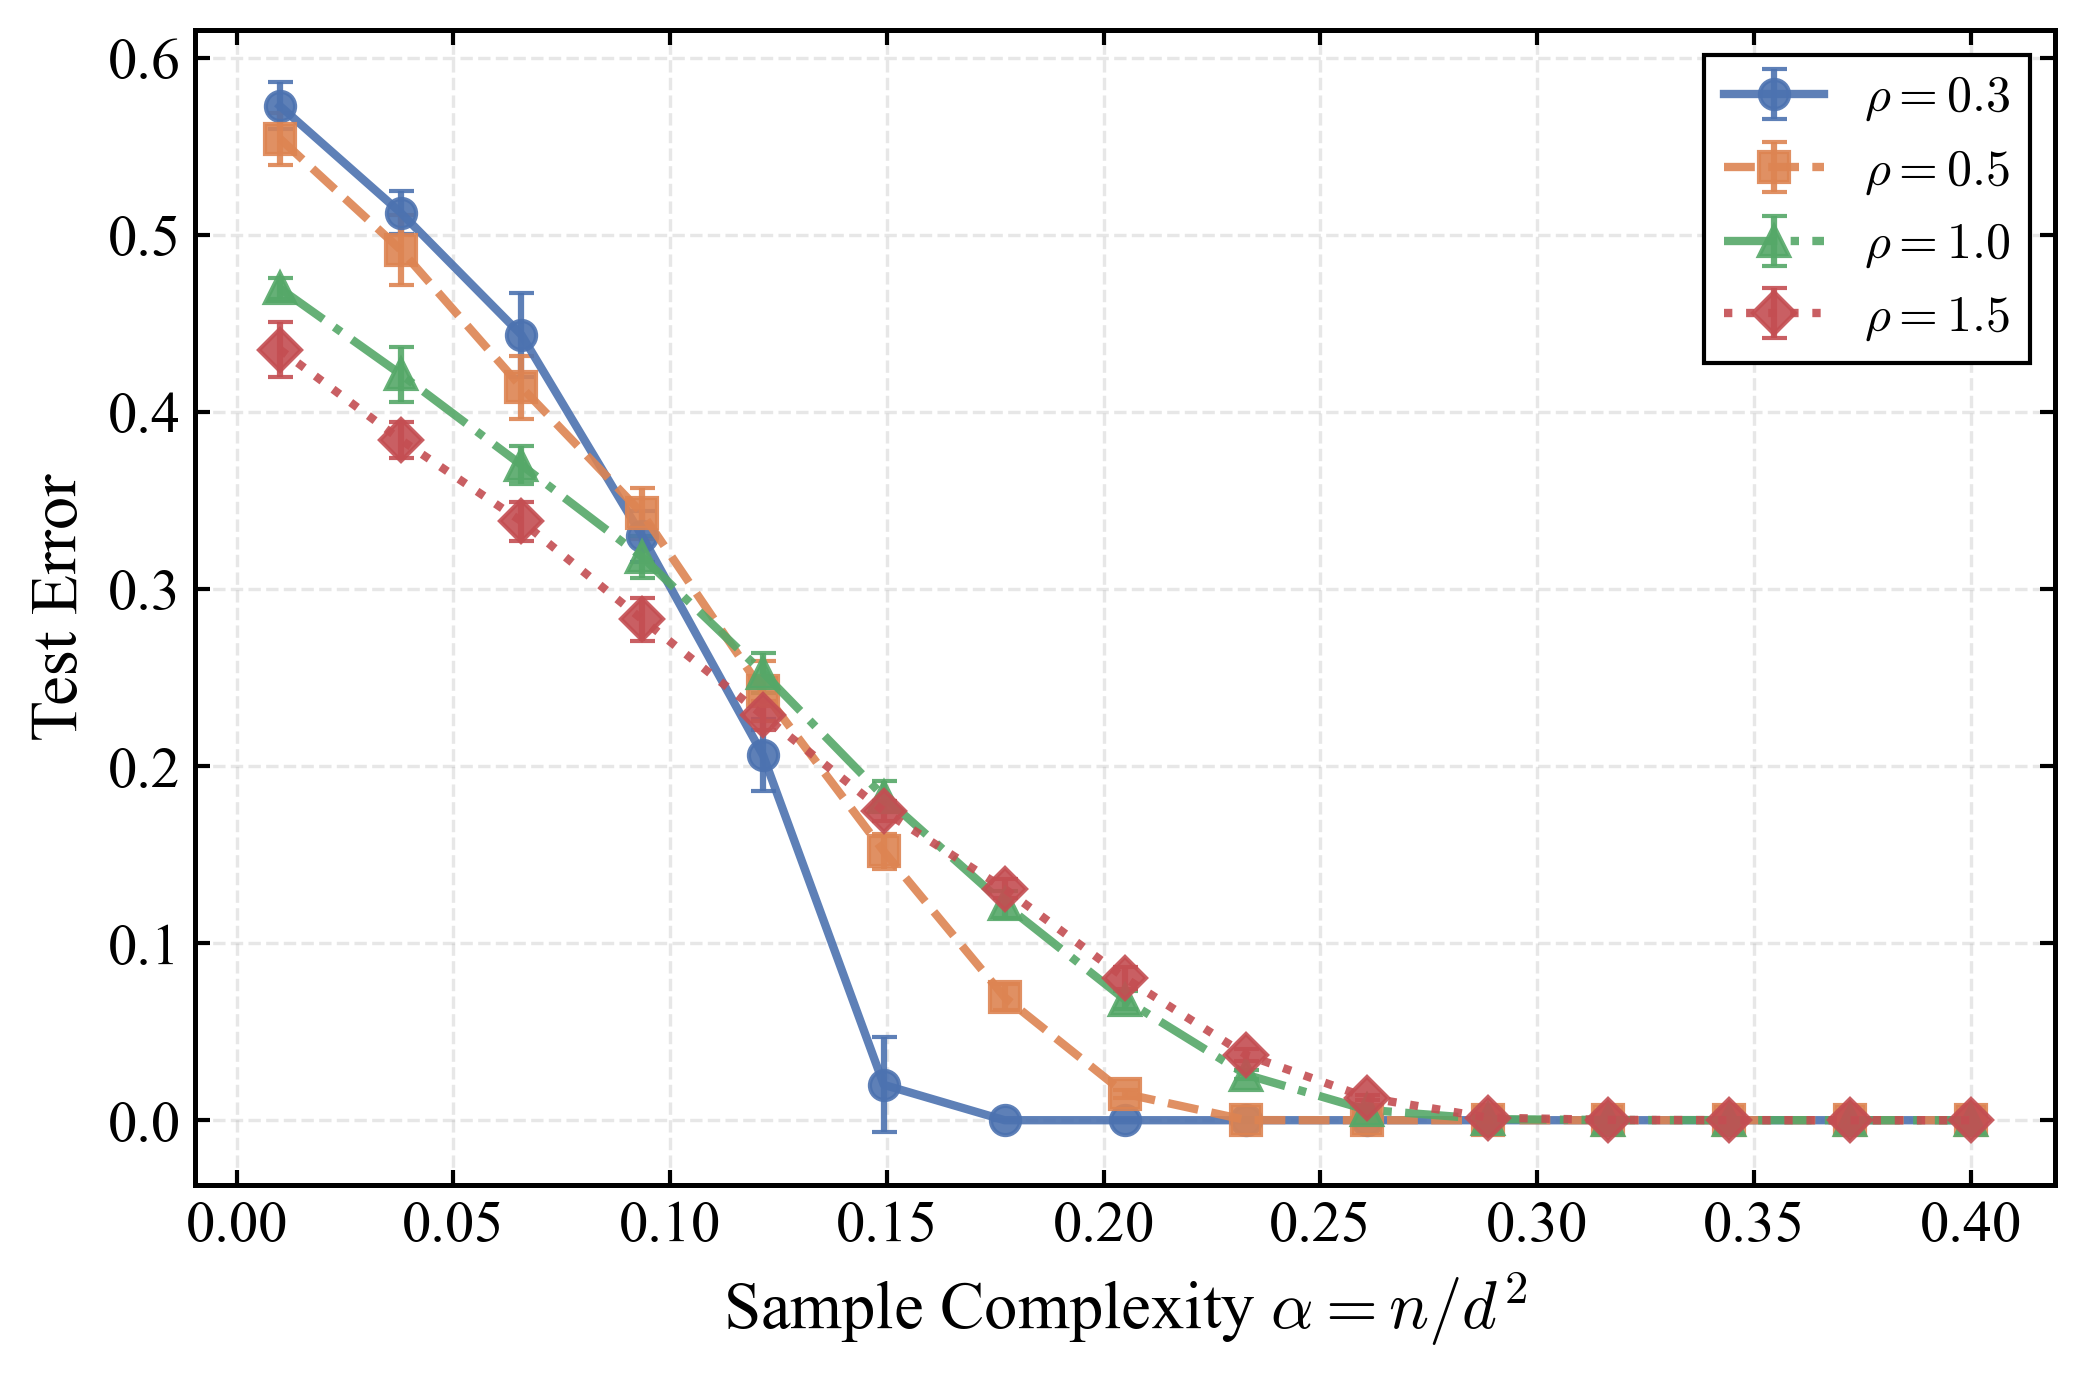

✅ Saved plot: ../results/run_20251222_1046/plots/TrainData_vs_alpha_run_20251222_1046.png


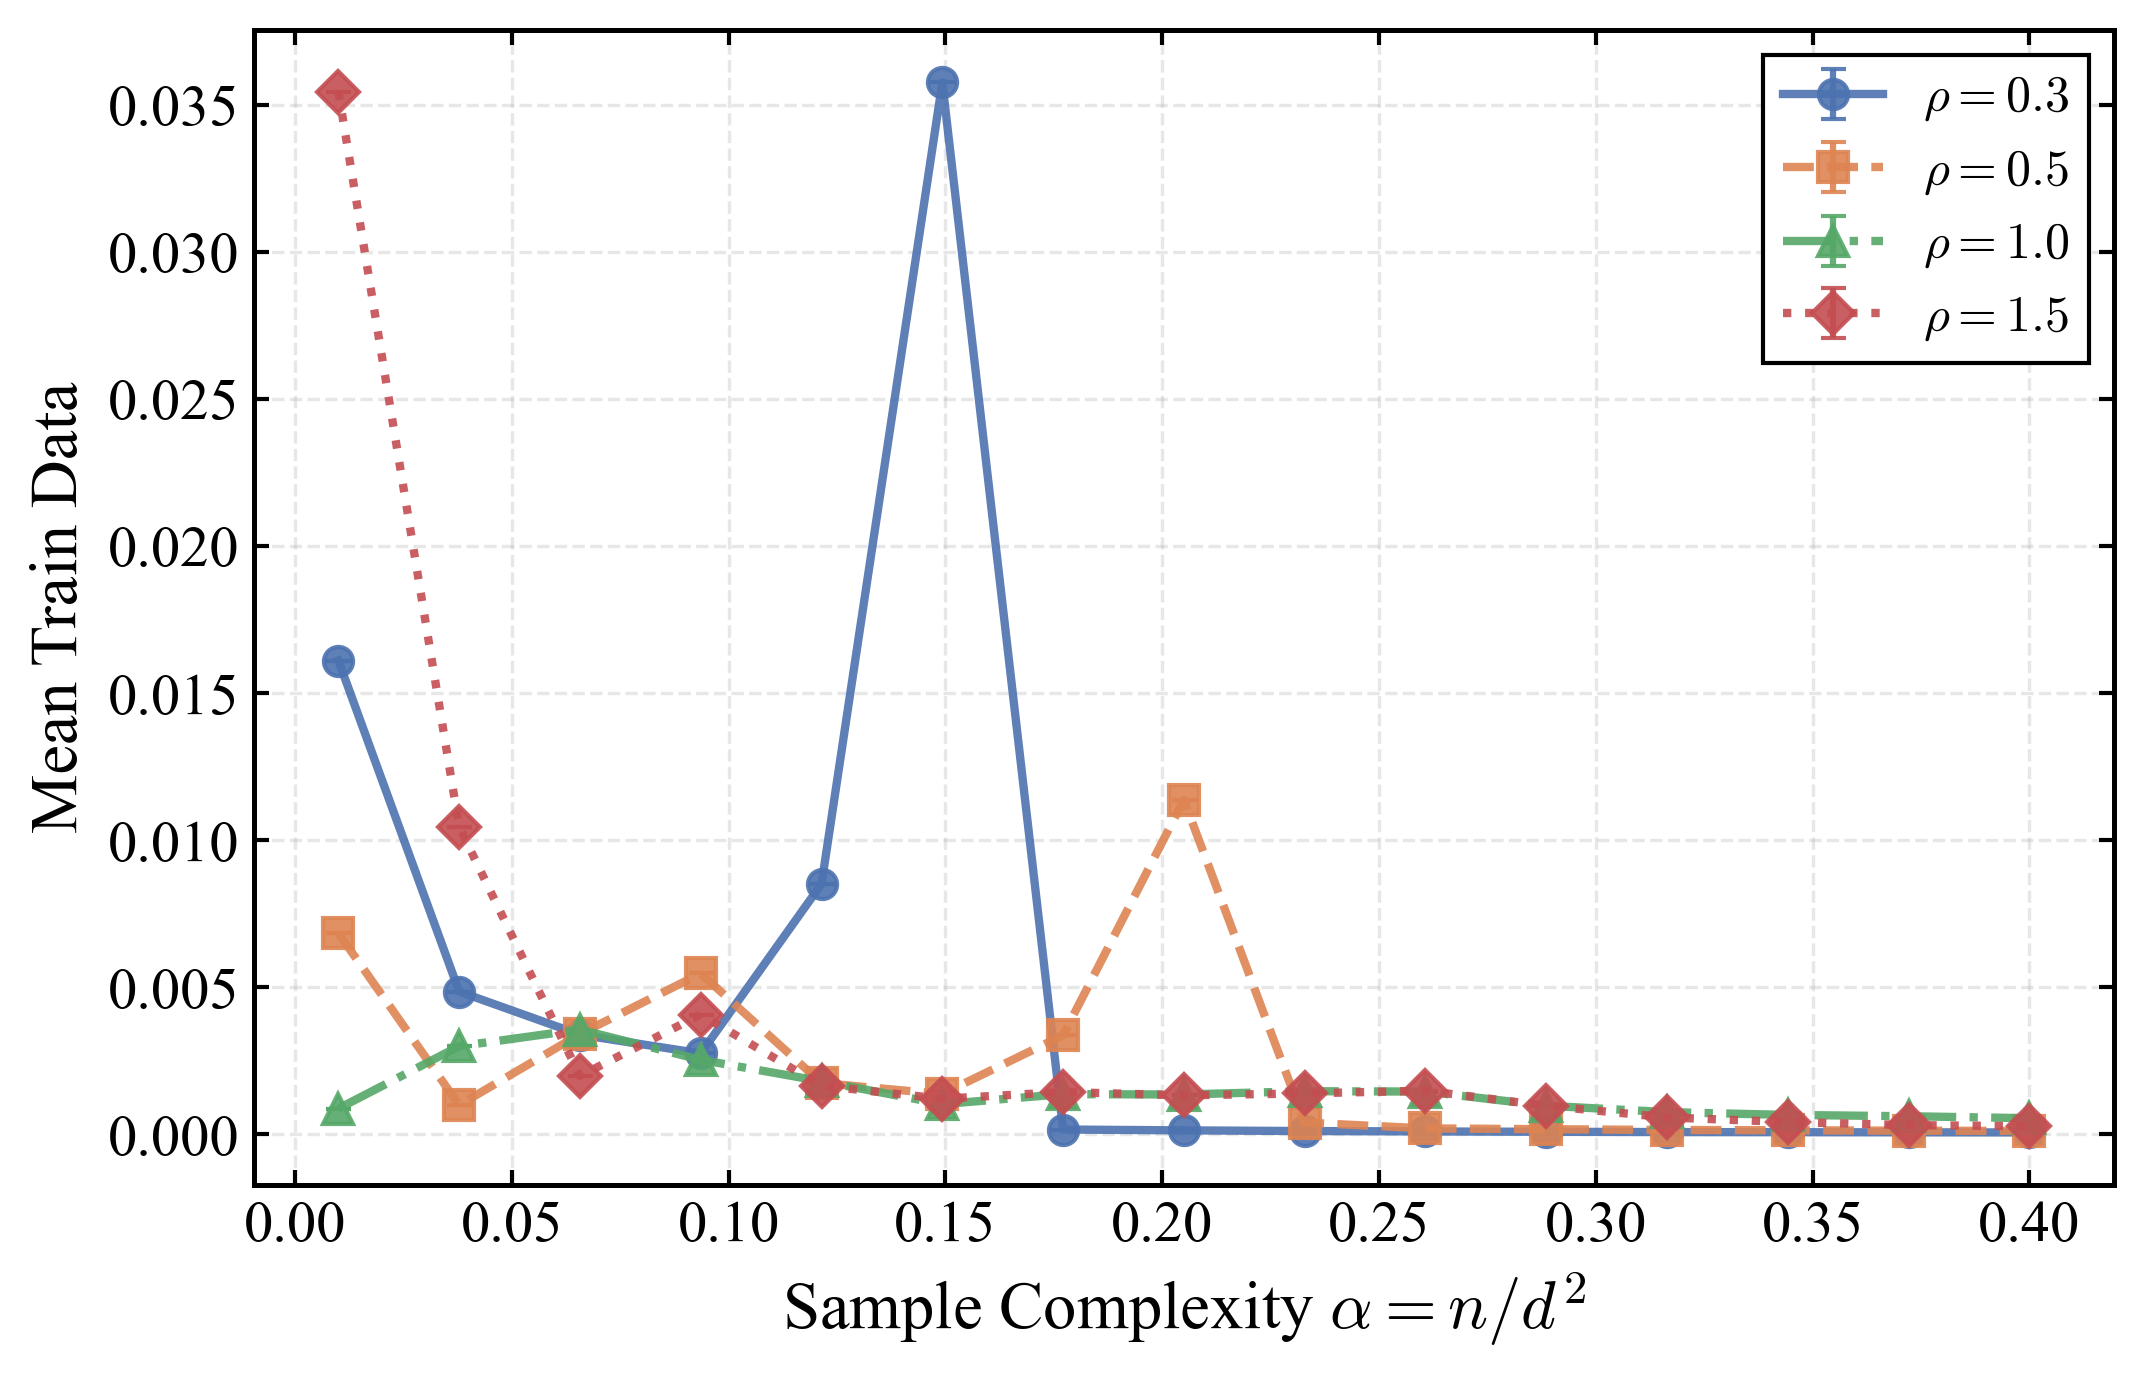

In [23]:
# --- 2. Chargement des données ---
base_path = f"../results/run_{run_id}/summary.csv"

if not os.path.exists(base_path):
    print(f"❌ Erreur : Fichier introuvable à {base_path}")
    # df = pd.DataFrame() # Fallback vide pour éviter le crash de l'IDE
else:
    df = pd.read_csv(base_path)
    print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- 3. Définition des Styles (Adapté pour Rho) ---
if 'df' in locals() and not df.empty:
    unique_rhos = sorted(df["rho"].unique())
    # Palette de couleurs distinctes
    colors = sns.color_palette("deep", n_colors=len(unique_rhos))
    markers = ['o', 's', '^', 'D', 'v', '<', '>']
    linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

    # --- 4. Fonction de Plot Générique ---
    def plot_rho_metric(df, y_col, y_err_col, ylabel, file_prefix, run_id):
        fig, ax = plt.subplots(figsize=(8, 5))
        
        # Boucle sur les Rhos
        for i, rho in enumerate(unique_rhos):
            subset = df[df["rho"] == rho].sort_values("alpha")
            
            # Style cyclique
            fmt_color = colors[i % len(colors)]
            fmt_marker = markers[i % len(markers)]
            fmt_ls = linestyles[i % len(linestyles)]
            
            ax.errorbar(
                subset["alpha"], 
                subset[y_col], 
                yerr=subset.get(y_err_col, 0),
                label=fr"$\rho={rho}$",  # Label LaTeX pour rho
                color=fmt_color,
                marker=fmt_marker,
                linestyle=fmt_ls,
                capsize=3,       # Jolis chapeaux pour les erreurs
                elinewidth=1.5,
                alpha=0.9
            )

        # --- Labels ---
        ax.set_xlabel(r"Sample Complexity $\alpha = n / d^2$")
        ax.set_ylabel(ylabel)

        # --- STYLE BOÎTE (Box Style) ---
        ax.set_axisbelow(True) 
        # Ticks intérieurs sur les 4 côtés
        ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
        
        # Bordures noires solides
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.2)
        
        # Légende
        ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc='best')
        
        # Sauvegarde
        filename = f"{file_prefix}_run_{run_id}.png"
        # Assurez-vous que plot_path est défini, sinon dossier courant
        save_full = os.path.join(plot_path, filename)
        
        plt.savefig(save_full)
        print(f"✅ Saved plot: {save_full}")
        plt.show()

    # --- 5. Génération des 3 Graphiques ---

    # 1. MSE
    plot_rho_metric(
        df, 
        y_col="MSE_mean", 
        y_err_col="MSE_std", 
        ylabel="Mean Squared Error (MSE)", 
        file_prefix="MSE_vs_alpha",
        run_id=run_id
    )

    # 2. Label Error
    plot_rho_metric(
        df, 
        y_col="label_err_mean", 
        y_err_col="label_err_std", 
        ylabel="Test Error", 
        file_prefix="LabelError_vs_alpha",
        run_id=run_id
    )

    # 3. Train Data
    plot_rho_metric(
        df, 
        y_col="train_data_mean", 
        y_err_col="train_data_std", 
        ylabel="Mean Train Data", 
        file_prefix="TrainData_vs_alpha",
        run_id=run_id
    )